In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# TotalSegmentator Baseline

## Loading TS results

In [39]:
data0 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/total_seg_output/contrast_phase_results_batch0.csv")
data1 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/total_seg_output/contrast_phase_results_batch1.csv")
data2 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/total_seg_output/contrast_phase_results_batch2.csv")
data3 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/total_seg_output/contrast_phase_results_batch3.csv")


data1
    

,pi_time,phase,probability,pi_time_min,pi_time_max,stddev,file
0,80.03,portal_venous,1.0,77.84,81.19,1.1685,NKI-d23231-00-0145_20070620_kalina99_0212.nii.gz
1,82.57,portal_venous,1.0,81.59,83.29,0.6462,NKI-d23231-00-0145_20071002_kalina99_0213.nii.gz
2,56.70,arterial_late,0.7,49.31,65.95,5.6282,NKI-d23231-00-0145_20080304_kalina99_0215.nii.gz
3,77.27,portal_venous,1.0,76.32,79.26,1.0410,NKI-d23231-00-0145_20080304_kalina99_0216.nii.gz
4,50.59,arterial_late,0.7,44.67,54.72,3.5907,NKI-d23231-00-0145_20090916_kalina99_0217.nii.gz
...,...,...,...,...,...,...,...
1388,76.10,portal_venous,1.0,75.12,78.47,1.2102,NKI-d23231-00-0292_20150407_kalina99_1135.nii.gz
1389,47.73,arterial_late,1.0,43.38,52.07,3.1476,NKI-d23231-00-0292_20150407_kalina99_1136.nii.gz
1390,77.90,portal_venous,1.0,76.26,80.24,1.3613,NKI-d23231-00-0292_20151026_kalina99_1137.nii.gz
1391,48.78,arterial_late,1.0,43.92,52.95,3.1085,NKI-d23231-00-0292_20151026_kalina99_1138.nii.gz


In [40]:
ts_data = pd.concat([data0, data1, data2, data3])
ts_data   # Error processing /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0818_20190322_kalina99_5441.nii.gz: Command '['totalseg_get_phase', '-i', np.str_('/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0818_20190322_kalina99_5441.nii.gz'), '-o', '/projects/net_contrast_classification/contrast_phase/total_seg_output/NKI-d23231-00-0818_20190322_kalina99_5441_phase.json']' returned non-zero exit status 1.

,pi_time,phase,probability,pi_time_min,pi_time_max,stddev,file
0,62.02,portal_venous,1.0,56.91,66.18,3.0706,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz
1,78.87,portal_venous,1.0,76.97,80.38,1.1980,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz
2,69.99,portal_venous,1.0,67.83,72.74,1.7276,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz
3,74.84,portal_venous,1.0,66.55,82.59,5.8700,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz
4,73.99,portal_venous,1.0,73.19,75.08,0.7242,NKI-d23231-00-0049_20090212_kalina01_0005.nii.gz
...,...,...,...,...,...,...,...
1387,80.39,portal_venous,1.0,78.27,82.66,1.4937,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz
1388,59.19,arterial_late,0.7,56.14,61.54,1.8509,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz
1389,77.28,portal_venous,1.0,74.66,78.94,1.6271,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz
1390,63.08,portal_venous,1.0,60.32,64.76,1.5287,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz


In [41]:
from pathlib import PureWindowsPath
import os

data = pd.read_csv("cleaned_data.csv")
data["file0"] = data["file"]
data["file"] = data["NiiFile"].apply(lambda x: PureWindowsPath(x).name)
data

,SubjectKeyRadiology,ExamDate,SegmentationBatch,NiiFile,SegNiiFile,file,is_liver_imaged,contrast,phase_timing,is_lesionfree,...,AcquisitionNumber,ConvolutionKernel,ExposureTime,XRayTubeCurrent,XRayExposure,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,file0
0,NKI-d23231-00-0063,2012-04-16,kalina01_0000,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,Partially,Arterial,Too Early,No,...,6.0,FC02,0.5,150,75,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,NaN,NET_0000_0000.nii.gz
1,NKI-d23231-00-0036,2014-02-18,kalina01_0002,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,Yes,Portal,Just Right,Yes,...,7.0,FC01,0.5,75,37,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,NaN,NET_0002_0000.nii.gz
2,NKI-d23231-00-0071,2013-09-24,kalina01_0003,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,Yes,Arterial,Just Right,Yes,...,3.0,B30f,0.5,168,84,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NET_0003_0000.nii.gz
3,NKI-d23231-00-0077,2014-12-22,kalina01_0004,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,Yes,Portal,Just Right,No,...,14.0,B25f,0.5,119,74,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NET_0004_0000.nii.gz
4,NKI-d23231-00-0049,2009-02-12,kalina01_0005,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0049_20090212_kalina01_0005.nii.gz,Yes,Portal,Just Right,Yes,...,14.0,B25f,0.5,280,140,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NET_0005_0000.nii.gz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5442,NKI-d23231-00-0888,2022-04-20,kalina99_5827,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,Yes,Portal,Just Right,No,...,6.0,B25f,0.5,158,98,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NET_5827_0000.nii.gz
5443,NKI-d23231-00-0888,2023-04-24,kalina99_5828,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,Yes,Arterial,Just Right,Yes,...,5.0,Bv38f\2,0.5,316,175,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NET_5828_0000.nii.gz
5444,NKI-d23231-00-0888,2023-04-24,kalina99_5829,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,Yes,Portal,Just Right,No,...,6.0,Bv38f\2,0.5,304,168,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NET_5829_0000.nii.gz
5445,NKI-d23231-00-0888,2023-08-01,kalina99_5830,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,Yes,Arterial,Just Right,Yes,...,5.0,Bv38f\2,0.5,167,92,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NET_5830_0000.nii.gz


In [42]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5447 entries, 0 to 5446
Data columns (total 40 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SubjectKeyRadiology                 5447 non-null   str    
 1   ExamDate                            5447 non-null   str    
 2   SegmentationBatch                   5447 non-null   str    
 3   NiiFile                             5447 non-null   str    
 4   SegNiiFile                          5447 non-null   str    
 5   file                                5447 non-null   str    
 6   is_liver_imaged                     5447 non-null   str    
 7   contrast                            5447 non-null   str    
 8   phase_timing                        5447 non-null   str    
 9   is_lesionfree                       5447 non-null   str    
 10  ai_segmentation_quality             3495 non-null   float64
 11  manual_segmentation_confidence      3495 non-null   fl

In [ ]:
merged_data = pd.merge(data, ts_data, on=["file"])

print("True contrast labels:\n", merged_data["contrast"].value_counts())
print("\n")
print("True timing labels:\n",merged_data["phase_timing"].value_counts())
print('\n')
print("TS labels:\n",merged_data["phase"].value_counts())


True contrast labels:
 contrast
Portal          3281
Arterial        2123
Non-contrast      42
Name: count, dtype: int64


True timing labels:
 phase_timing
Just Right      4502
Too Early        759
Too Late         148
Non-contrast      37
Name: count, dtype: int64


TS labels:
 phase
portal_venous     3922
arterial_late     1482
native              30
arterial_early      12
Name: count, dtype: int64


In [ ]:
# Create TS phase
merged_data["TS_contrast"] = merged_data["phase"].apply(lambda x: x.split("_")[0].capitalize() if "_" in x else 'Non-contrast')

# merged_data["TS_timing"] = merged_data["phase"].apply(lambda x: x.split("_")[1].capitalize() if "_" in x else "Non-contrast")
# merged_data["TS_timing"] = merged_data["TS_timing"].apply(lambda x: "Just Right" if x == 'Venous' else x)
# merged_data["TS_timing"] = merged_data["TS_timing"].apply(lambda x: "Too Early" if x == 'Early' else x)
# merged_data["TS_timing"] = merged_data["TS_timing"].apply(lambda x: "Too Late" if x == 'Late' else x)


# merged_data.loc[merged_data["contrast"] == "Non-contrast","phase_timing"] = "Non-contrast"
# mask = (
#     merged_data["contrast"] != "Non-contrast"
# ) & (
#     merged_data["phase_timing"] == "Non-contrast"
# )

# merged_data.loc[mask, "phase_timing"] = "Just Right"

print('After renaming:')
print("True labels:\n", merged_data["contrast"].value_counts())
print("\n")
print("TS labels:\n",merged_data["TS_contrast"].value_counts()) # Early AP and Late AP from TS are merged in AP

After renaming:
True labels:
 contrast
Portal          3281
Arterial        2123
Non-contrast      42
Name: count, dtype: int64


TS labels:
 TS_contrast
Portal          3922
Arterial        1494
Non-contrast      30
Name: count, dtype: int64


## Arterial vs. Portal vs. NC

In [58]:
merged_data.head(5)

,SubjectKeyRadiology,ExamDate,SegmentationBatch,NiiFile,SegNiiFile,file,is_liver_imaged,contrast,phase_timing,is_lesionfree,...,ConversionSoftwareVersion,BodyPartExamined,file0,pi_time,phase,probability,pi_time_min,pi_time_max,stddev,TS_contrast
0,NKI-d23231-00-0063,2012-04-16,kalina01_0000,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,Partially,Arterial,Too Early,No,...,v1.0.20230411,NaN,NET_0000_0000.nii.gz,62.02,portal_venous,1.0,56.91,66.18,3.0706,Portal
1,NKI-d23231-00-0036,2014-02-18,kalina01_0002,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,Yes,Portal,Just Right,Yes,...,v1.0.20230411,NaN,NET_0002_0000.nii.gz,78.87,portal_venous,1.0,76.97,80.38,1.1980,Portal
2,NKI-d23231-00-0071,2013-09-24,kalina01_0003,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,Yes,Arterial,Just Right,Yes,...,v1.0.20230411,ABDOMEN,NET_0003_0000.nii.gz,69.99,portal_venous,1.0,67.83,72.74,1.7276,Portal
3,NKI-d23231-00-0077,2014-12-22,kalina01_0004,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,Yes,Portal,Just Right,No,...,v1.0.20230411,ABDOMEN,NET_0004_0000.nii.gz,74.84,portal_venous,1.0,66.55,82.59,5.8700,Portal
4,NKI-d23231-00-0049,2009-02-12,kalina01_0005,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0049_20090212_kalina01_0005.nii.gz,Yes,Portal,Just Right,Yes,...,v1.0.20230411,ABDOMEN,NET_0005_0000.nii.gz,73.99,portal_venous,1.0,73.19,75.08,0.7242,Portal


In [59]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_true = le.fit_transform(merged_data["contrast"])
y_pred = le.fit_transform(merged_data['TS_contrast'])

print('Contrast classification accuracy:', round(accuracy_score(y_true, y_pred),3))
print("Classification report:\n", classification_report(y_true, y_pred, target_names=le.classes_))

Contrast classification accuracy: 0.874
Classification report:
               precision    recall  f1-score   support

    Arterial       0.99      0.69      0.81      2123
Non-contrast       0.93      0.67      0.78        42
      Portal       0.83      0.99      0.91      3281

    accuracy                           0.87      5446
   macro avg       0.92      0.78      0.83      5446
weighted avg       0.89      0.87      0.87      5446



In [60]:
misclassified = merged_data[
    merged_data['contrast'] != merged_data['TS_contrast']
]
misclassified

,SubjectKeyRadiology,ExamDate,SegmentationBatch,NiiFile,SegNiiFile,file,is_liver_imaged,contrast,phase_timing,is_lesionfree,...,ConversionSoftwareVersion,BodyPartExamined,file0,pi_time,phase,probability,pi_time_min,pi_time_max,stddev,TS_contrast
0,NKI-d23231-00-0063,2012-04-16,kalina01_0000,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,Partially,Arterial,Too Early,No,...,v1.0.20230411,NaN,NET_0000_0000.nii.gz,62.02,portal_venous,1.0,56.91,66.18,3.0706,Portal
2,NKI-d23231-00-0071,2013-09-24,kalina01_0003,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,Yes,Arterial,Just Right,Yes,...,v1.0.20230411,ABDOMEN,NET_0003_0000.nii.gz,69.99,portal_venous,1.0,67.83,72.74,1.7276,Portal
23,NKI-d23231-00-0006,2015-02-09,kalina01_0041,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0006_20150209_kalina01_0041.nii.gz,Yes,Arterial,Just Right,Yes,...,v1.0.20230411,NaN,NET_0041_0000.nii.gz,62.98,portal_venous,1.0,60.28,66.94,2.7831,Portal
26,NKI-d23231-00-0040,2015-05-18,kalina01_0049,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0040_20150518_kalina01_0049.nii.gz,Yes,Arterial,Just Right,No,...,v1.0.20230411,NaN,NET_0049_0000.nii.gz,61.43,portal_venous,1.0,59.96,66.98,2.7743,Portal
31,NKI-d23231-00-0095,2011-09-01,kalina01_0054,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0095_20110901_kalina01_0054.nii.gz,Yes,Arterial,Too Late,No,...,v1.0.20230411,ABDOMEN,NET_0054_0000.nii.gz,65.40,portal_venous,1.0,60.61,71.02,3.7450,Portal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5395,NKI-d23231-00-0875,2023-08-02,kalina99_5760,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0875_20230802_kalina99_5760.nii.gz,Yes,Arterial,Just Right,No,...,v1.0.20230411,ABDOMEN,NET_5760_0000.nii.gz,66.60,portal_venous,1.0,65.59,68.29,0.9629,Portal
5405,NKI-d23231-00-0879,2021-09-29,kalina99_5775,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0879_20210929_kalina99_5775.nii.gz,Yes,Arterial,Just Right,Yes,...,v1.0.20230411,ABDOMEN,NET_5775_0000.nii.gz,62.41,portal_venous,1.0,60.82,64.50,1.2733,Portal
5426,NKI-d23231-00-0882,2022-08-29,kalina99_5801,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0882_20220829_kalina99_5801.nii.gz,Yes,Arterial,Just Right,Yes,...,v1.0.20230411,ABDOMEN,NET_5801_0000.nii.gz,60.33,portal_venous,1.0,53.97,67.14,4.2907,Portal
5433,NKI-d23231-00-0887,2021-08-25,kalina99_5811,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0887_20210825_kalina99_5811.nii.gz,Yes,Arterial,Just Right,No,...,v1.0.20230411,ABDOMEN,NET_5811_0000.nii.gz,60.58,portal_venous,1.0,56.17,67.01,3.6689,Portal


In [61]:
print("Confusion matrix:")
pd.crosstab(
    merged_data['contrast'],
    merged_data['TS_contrast'],
    margins=True
)

Confusion matrix:


TS_contrast,Arterial,Non-contrast,Portal,All
contrast,,,,
Arterial,1473,0,650,2123
Non-contrast,3,28,11,42
Portal,18,2,3261,3281
All,1494,30,3922,5446


In [88]:
misclassified[['file', 'is_liver_imaged', 'contrast', 'phase_timing', 'TS_contrast', 'phase', 'high_signal_to_noise',
                'metal_artifacts','AcquisitionTime', 'ProtocolName', 'pi_time', 'probability', 'pi_time_min',
                'pi_time_max']].sort_values(by=['file'], ascending=[True])

,file,is_liver_imaged,contrast,phase_timing,TS_contrast,phase,high_signal_to_noise,metal_artifacts,AcquisitionTime,ProtocolName,pi_time,probability,pi_time_min,pi_time_max
460,NKI-d23231-00-0001_20120619_kalina12_0027.nii.gz,Yes,Arterial,Too Late,Portal,portal_venous,False,False,27:59.2,ABDOMEN + C 1.0 FC02,79.05,1.0,78.15,80.64
70,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,Yes,Arterial,Too Late,Portal,portal_venous,False,False,03:50.2,Maag.abdomen 1.5 B25f,60.74,1.0,57.24,65.44
331,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,Yes,Arterial,Just Right,Portal,portal_venous,False,False,10:30.9,ABDOMEN + C 1.0 FC01,71.92,1.0,69.64,74.95
72,NKI-d23231-00-0005_20221017_kalina02_0055.nii.gz,Yes,Arterial,Just Right,Portal,portal_venous,False,False,18:44.4,Abd laat-art 1.0 Bv38 2,67.70,1.0,63.97,73.61
448,NKI-d23231-00-0006_20140530_kalina12_0007.nii.gz,Yes,Arterial,Just Right,Portal,portal_venous,False,False,05:37.2,ABDOMEN A 1.0 FC01,67.87,1.0,64.70,72.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5405,NKI-d23231-00-0879_20210929_kalina99_5775.nii.gz,Yes,Arterial,Just Right,Portal,portal_venous,False,False,22:34.0,Abd laat-art 1.0 Bv38 2,62.41,1.0,60.82,64.50
1970,NKI-d23231-00-0879_20220518_kalina01_0517.nii.gz,Yes,Arterial,Just Right,Portal,portal_venous,False,False,07:09.9,Abd laat-art 1.0 Bv38 2,64.55,1.0,63.11,66.91
5426,NKI-d23231-00-0882_20220829_kalina99_5801.nii.gz,Yes,Arterial,Just Right,Portal,portal_venous,False,False,56:41.6,Abd laat-art 1.0 Bv38 2,60.33,1.0,53.97,67.14
5433,NKI-d23231-00-0887_20210825_kalina99_5811.nii.gz,Yes,Arterial,Just Right,Portal,portal_venous,False,False,31:51.5,Abdomen A 1.5 B25f,60.58,1.0,56.17,67.01


In [65]:
misclassified.is_liver_imaged.value_counts()

is_liver_imaged
Yes          646
Partially     30
0              8
Name: count, dtype: int64

In [66]:
misclassified = misclassified[misclassified.is_liver_imaged != '0']
misclassified.is_liver_imaged.value_counts()

is_liver_imaged
Yes          646
Partially     30
Name: count, dtype: int64

In [ ]:
from monai.transforms import LoadImage, EnsureChannelFirst

samples = (misclassified.groupby("contrast")
           .apply(lambda x: x.sample(n=min(3, len(x)), random_state=42))
           .reset_index()
                   )[['file', 'is_liver_imaged', 'contrast', 'TS_contrast', 'phase', 'high_signal_to_noise',
                'metal_artifacts','AcquisitionTime', 'ProtocolName']]


files = list(samples['file'])
phases = list(samples['contrast'])
folder_path = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET"


def data_load(folder_dir, files, channel_first = True):
    images = []   
    loader = LoadImage(image_only=True)
    
    for file in files:
        file_dir = os.path.join(folder_dir, PureWindowsPath(file).name)
        ct = loader(file_dir)
        if channel_first:
            ct = EnsureChannelFirst()(ct)

        ct = ct.numpy()
        images.append(ct)

    return images


misclass_images = data_load(folder_path, files)

In [91]:
samples

,file,is_liver_imaged,contrast,TS_contrast,phase,high_signal_to_noise,metal_artifacts,AcquisitionTime,ProtocolName
0,NKI-d23231-00-0865_20220623_kalina99_5717.nii.gz,Yes,Arterial,Portal,portal_venous,False,False,57:39.4,Abd laat-art 1.0 Bv38 2
1,NKI-d23231-00-0227_20130212_kalina99_0318.nii.gz,Yes,Arterial,Portal,portal_venous,False,False,41:58.9,ABDOMEN A 1.0 FC02
2,NKI-d23231-00-0795_20190131_kalina99_5279.nii.gz,Yes,Arterial,Portal,portal_venous,False,False,16:52.6,Abdomen A 1.5 B25f
3,NKI-d23231-00-0170_20060405_kalina99_0444.nii.gz,Yes,Non-contrast,Portal,portal_venous,False,False,37:00.0,Abdomen 1.5 B25f
4,NKI-d23231-00-0193_20161012_kalina99_0660.nii.gz,Yes,Non-contrast,Portal,portal_venous,False,False,51:49.3,Body 1.0 CE Vol.
5,NKI-d23231-00-0532_20150818_kalina99_3669.nii.gz,Yes,Non-contrast,Portal,portal_venous,False,False,46:10.3,Abdomen V 1.5 B25f
6,NKI-d23231-00-0024_20210423_kalina08_0039.nii.gz,Yes,Portal,Arterial,arterial_late,False,False,56:59.6,Body 1.0 CE Vol.
7,NKI-d23231-00-0653_20201014_kalina99_4513.nii.gz,Yes,Portal,Arterial,arterial_late,False,False,26:43.3,ThorAbd 1.0 Bv38 2
8,NKI-d23231-00-0615_20171021_kalina99_4355.nii.gz,Yes,Portal,Arterial,arterial_late,False,False,57:15.9,Body 1.0 CE Vol.


In [92]:
misclass_images[8].shape

(1, 512, 512, 127)

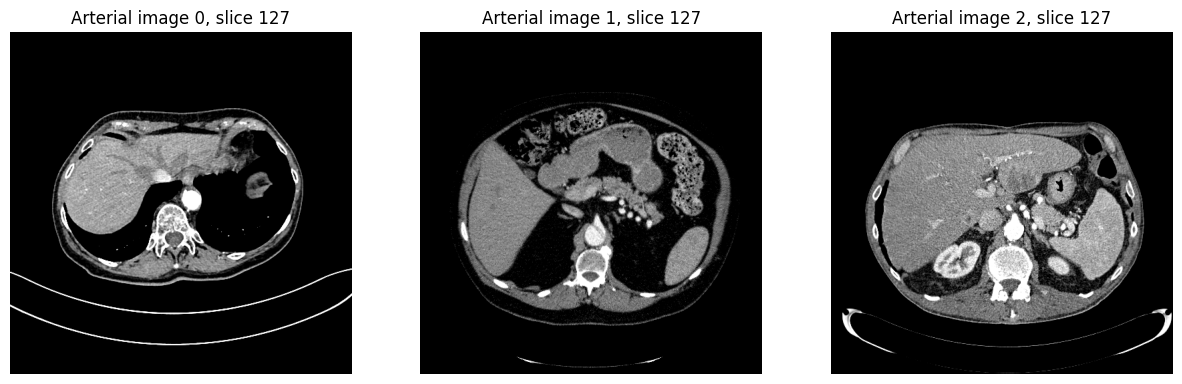

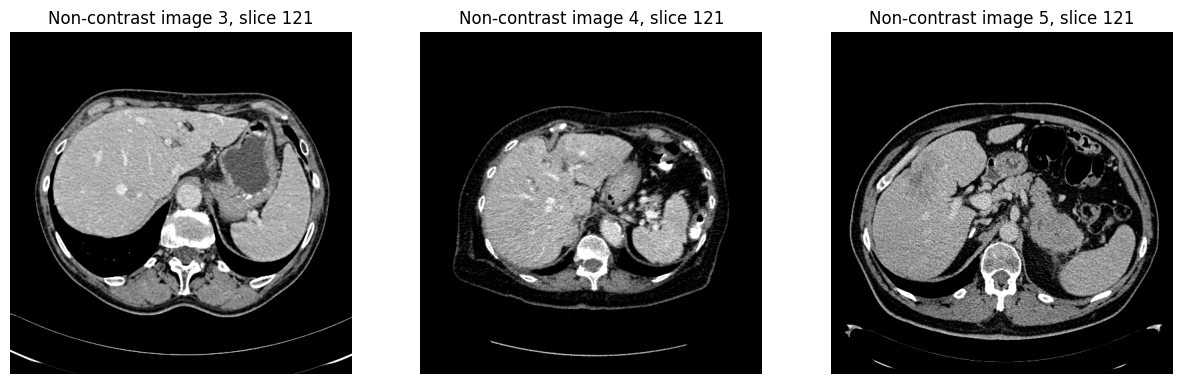

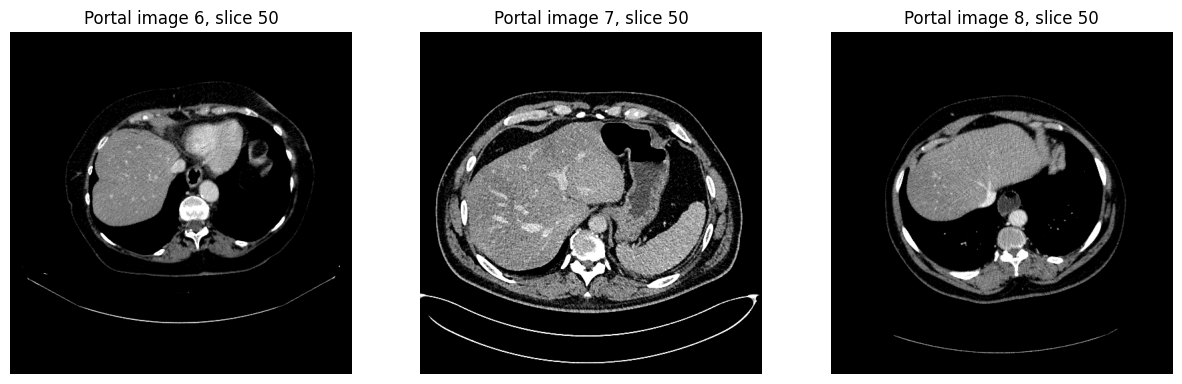

In [ ]:
def show_slices_per_class(images, center=50, width=300):

    def window_ct(img, center, width):
        low = center - width/2
        high = center + width/2
        return img.clip(low, high)


    class_ranges = {
        "Arterial": range(0, 3),
        "Non-contrast": range(3, 6),
        "Portal": range(6, 9)
    }

    for cls_name, indices in class_ranges.items():

        z = int(np.mean([images[i].shape[3] for i in indices])) - 30
        if cls_name == 'Portal':
            z = 50
        else:
            z = int(np.mean([images[i].shape[3] for i in indices])) - 30

        plt.figure(figsize=(15,5))
        for j, i in enumerate(indices):
            img = images[i][0, :, :, z]
            plt.subplot(1, 3, j+1)
            plt.imshow(np.rot90(window_ct(img, center, width),k=1), cmap="gray")
            plt.title(f"{cls_name} image {i}, slice {z}")
            plt.axis("off")
        plt.show()

show_slices_per_class(misclass_images)

## Phase + Timing Classification Results

In [ ]:
# merged_data.loc[merged_data["contrast"] == "Portal","phase_timing"] = "Just Right"

# merged_data["phase_timing_combined"] = (merged_data["contrast"].str.cat(merged_data["phase_timing"], sep=" "))
# merged_data["TS_phase_timing_combined"] = (merged_data["TS_contrast"].str.cat(merged_data["TS_timing"], sep=" "))

# print(merged_data["phase_timing_combined"].value_counts())
# print("\n")
# print(merged_data["TS_phase_timing_combined"].value_counts())


# contrast_correct = merged_data[merged_data["contrast"] == merged_data["TS_contrast"]].copy()

# y_true = le.fit_transform(contrast_correct["phase_timing"])
# y_pred = le.fit_transform(contrast_correct['TS_timing'])

# print('Timing classification accuracy:', round(accuracy_score(y_true, y_pred),3))
# print("Classification report:\n", classification_report(y_true, y_pred, target_names=le.classes_))

# print("Confusion matrix:")
# pd.crosstab(
#     contrast_correct["phase_timing"],
#     contrast_correct['TS_timing'],
#     margins=True
# )

phase_timing_combined
Portal Just Right            3133
Arterial Just Right          1365
Arterial Too Early            661
Arterial Too Late              97
Portal Too Early               97
Portal Too Late                51
Non-contrast Non-contrast      42
Name: count, dtype: int64


TS_phase_timing_combined
Portal Just Right            3922
Arterial Too Late            1482
Non-contrast Non-contrast      30
Arterial Too Early             12
Name: count, dtype: int64


## Time Interval Estimation

### All data except NC

In [156]:
contrast_data = merged_data[merged_data["contrast"] !='Non-contrast'] # ignore the NC images as they are only 42 
cols = ['SubjectKeyRadiology', 'ExamDate','file', 'is_liver_imaged', 
        'contrast', 'phase_timing', 'TS_contrast', 'phase', 'AcquisitionTime','pi_time',
        'pi_time_min', 'pi_time_max', 'stddev']

contrast_data=contrast_data.sort_values(by=['SubjectKeyRadiology', 'ExamDate','AcquisitionTime'], ascending=[True, True, True]).reset_index()
contrast_data[cols]

,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,phase_timing,TS_contrast,phase,AcquisitionTime,pi_time,pi_time_min,pi_time_max,stddev
0,NKI-d23231-00-0001,2006-09-20,NKI-d23231-00-0001_20060920_kalina12_0045.nii.gz,Yes,Portal,Too Early,Portal,portal_venous,07:42.5,85.59,82.12,93.46,4.2121
1,NKI-d23231-00-0001,2007-06-08,NKI-d23231-00-0001_20070608_kalina03_0023.nii.gz,Yes,Portal,Just Right,Portal,portal_venous,47:19.2,82.55,80.15,83.99,1.3290
2,NKI-d23231-00-0001,2007-08-15,NKI-d23231-00-0001_20070815_kalina99_0002.nii.gz,Yes,Portal,Too Early,Portal,portal_venous,51:28.0,65.44,62.05,67.68,1.8933
3,NKI-d23231-00-0001,2007-08-15,NKI-d23231-00-0001_20070815_kalina14_0007.nii.gz,Yes,Portal,Just Right,Portal,portal_venous,51:53.0,74.22,71.60,77.96,2.7185
4,NKI-d23231-00-0001,2008-03-17,NKI-d23231-00-0001_20080317_kalina08_0037.nii.gz,Yes,Arterial,Too Early,Arterial,arterial_late,31:03.0,53.44,47.63,58.94,3.7340
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,NKI-d23231-00-0888,2022-04-20,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,Yes,Portal,Just Right,Portal,portal_venous,13:16.1,80.39,78.27,82.66,1.4937
5400,NKI-d23231-00-0888,2023-04-24,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,Yes,Arterial,Just Right,Arterial,arterial_late,05:45.6,59.19,56.14,61.54,1.8509
5401,NKI-d23231-00-0888,2023-04-24,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,Yes,Portal,Just Right,Portal,portal_venous,06:20.1,77.28,74.66,78.94,1.6271
5402,NKI-d23231-00-0888,2023-08-01,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,Yes,Arterial,Just Right,Portal,portal_venous,43:20.6,63.08,60.32,64.76,1.5287


In [157]:
subset = ['SubjectKeyRadiology', 'ExamDate', 
            'contrast', 'phase_timing', 'AcquisitionTime','pi_time',
            'phase','TS_contrast', 'ProtocolName', 
            'is_liver_imaged', 'high_signal_to_noise','metal_artifacts']

print('Same acquisition time, different time prediction due to reconstruction kernel')
contrast_data[subset][contrast_data.SubjectKeyRadiology == 'NKI-d23231-00-0281'].head(2)

Same acquisition time, different time prediction due to reconstruction kernel


,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,pi_time,phase,TS_contrast,ProtocolName,is_liver_imaged,high_signal_to_noise,metal_artifacts
2251,NKI-d23231-00-0281,2014-05-20,Portal,Just Right,31:15.2,71.85,portal_venous,Portal,ThxAbd 1.5 B25f,Yes,False,False
2252,NKI-d23231-00-0281,2014-05-20,Portal,Just Right,31:15.2,70.51,portal_venous,Portal,ThxAbd 3.0 B31f,Yes,False,False


In [158]:
def time_to_seconds(t):
    minutes, seconds = t.split(':')
    return int(minutes) * 60 + float(seconds)

unique_keys = ["SubjectKeyRadiology", "ExamDate", "ConvolutionKernel"]

contrast_data['AcquisitionTime_sec'] = contrast_data['AcquisitionTime'].apply(time_to_seconds)

contrast_data["time_interval"] = (
    contrast_data
    .groupby(unique_keys)["AcquisitionTime_sec"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
)

contrast_data["TS_time_interval"] = (
    contrast_data
    .groupby(unique_keys)["pi_time"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
    )

In [159]:

# def mmss_to_seconds(mmss):
#     m, s = mmss.split(":")
#     return int(m) * 60 + float(s)

# def compute_time_intervals(group):
#     # Single-entry group → NaN
#     if len(group) == 1:
#         return pd.Series(np.nan, index=group.index)

#     # Convert to seconds in ORIGINAL ORDER
#     secs = group['AcquisitionTime'].apply(mmss_to_seconds).values
#     adjusted = secs.copy()

#     # Handle wrap-around (59 → 00)
#     for i in range(1, len(secs)):
#         if secs[i] < secs[i - 1]:
#             adjusted[i] += 3600

#     diffs = pd.Series(adjusted).diff()

#     # Same interval for both rows
#     diffs.iloc[0] = diffs.iloc[1]

#     return pd.Series(diffs.values, index=group.index)


contrast_data['time_interval'] = contrast_data['time_interval'].apply(lambda x: 3600 - abs(x) if abs(x) > 3500 else x)

cols = ['SubjectKeyRadiology', 'ExamDate','contrast', 'phase_timing',
        'AcquisitionTime', 'time_interval','pi_time', 'TS_time_interval',
        'phase', 'TS_contrast', 'ProtocolName', 'ConvolutionKernel']

contrast_data[cols][contrast_data.SubjectKeyRadiology == 'NKI-d23231-00-0281']

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,time_interval,pi_time,TS_time_interval,phase,TS_contrast,ProtocolName,ConvolutionKernel
2251,NKI-d23231-00-0281,2014-05-20,Portal,Just Right,31:15.2,NaN,71.85,NaN,portal_venous,Portal,ThxAbd 1.5 B25f,B25f
2252,NKI-d23231-00-0281,2014-05-20,Portal,Just Right,31:15.2,NaN,70.51,NaN,portal_venous,Portal,ThxAbd 3.0 B31f,B31f
2253,NKI-d23231-00-0281,2014-07-29,Arterial,Just Right,05:34.1,24.2,43.25,31.18,arterial_late,Arterial,ABDOMEN A 1.0 FC01,FC01
2254,NKI-d23231-00-0281,2014-07-29,Portal,Just Right,05:58.3,24.2,74.43,31.18,portal_venous,Portal,ABDOMEN + C 1.0 FC01,FC01
2255,NKI-d23231-00-0281,2014-10-27,Portal,Just Right,00:23.0,30.2,74.27,-30.57,portal_venous,Portal,ABDOMEN + C 1.0 FC01,FC01
2256,NKI-d23231-00-0281,2014-10-27,Arterial,Just Right,59:52.8,30.2,43.70,-30.57,arterial_late,Arterial,ABDOMEN A 1.0 FC01,FC01
2257,NKI-d23231-00-0281,2015-01-26,Arterial,Just Right,55:11.5,28.0,56.66,18.66,arterial_late,Arterial,ABDOMEN A 1.0 FC01,FC01
2258,NKI-d23231-00-0281,2015-01-26,Portal,Just Right,55:39.5,28.0,75.32,18.66,portal_venous,Portal,ABDOMEN + C 1.0 FC01,FC01
2259,NKI-d23231-00-0281,2015-08-19,Arterial,Just Right,00:24.5,30.2,44.46,33.08,arterial_late,Arterial,ABDOMEN A 1.0 FC01,FC01
2260,NKI-d23231-00-0281,2015-08-19,Portal,Just Right,00:54.7,30.2,77.54,33.08,portal_venous,Portal,ABDOMEN + C 1.0 FC01,FC01


In [160]:
# ASK - more than 3 entries per exam (due to different protocols or incorrect NC labels)
multi_phase = (
    contrast_data
    .groupby(unique_keys)
    .filter(lambda x: len(x) > 2)
)

multi_phase[cols].sort_values(
        by=['SubjectKeyRadiology', 'ExamDate', 'AcquisitionTime'])

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,time_interval,pi_time,TS_time_interval,phase,TS_contrast,ProtocolName,ConvolutionKernel
933,NKI-d23231-00-0109,2006-12-14,Portal,Just Right,10:56.4,94.7,0.09,46.52,native,Non-contrast,Lever -C 1.5 B25f,B25f
934,NKI-d23231-00-0109,2006-12-14,Arterial,Just Right,12:31.1,288.5,46.61,5.30,arterial_late,Arterial,Lever A 1.5 B25f,B25f
935,NKI-d23231-00-0109,2006-12-14,Portal,Just Right,17:19.6,288.5,51.91,5.30,arterial_late,Arterial,Lever 5 min. 1.5 B25f,B25f
1143,NKI-d23231-00-0149,2007-03-20,Arterial,Just Right,56:51.4,36.4,52.44,17.45,arterial_late,Arterial,Arterial Phase 3.0 B25f,B25f
1144,NKI-d23231-00-0149,2007-03-20,Portal,Just Right,57:27.8,106.6,69.89,10.31,portal_venous,Portal,Venous Phase 3.0 B25f,B25f
1145,NKI-d23231-00-0149,2007-03-20,Portal,Just Right,59:14.4,106.6,80.20,10.31,portal_venous,Portal,Delayed Phase 3.0 B25f,B25f
1212,NKI-d23231-00-0152,2012-08-10,Arterial,Just Right,30:41.0,22.3,66.05,1.06,portal_venous,Portal,LEVER A 1.0 FC02,FC02
1213,NKI-d23231-00-0152,2012-08-10,Portal,Just Right,31:03.3,23.5,67.11,15.09,portal_venous,Portal,MEDIASTINUM +C 1.0 FC02,FC02
1214,NKI-d23231-00-0152,2012-08-10,Portal,Just Right,31:26.8,23.5,82.20,15.09,portal_venous,Portal,ABDOMEN + C 1.0 FC02,FC02
1317,NKI-d23231-00-0168,2005-04-12,Arterial,Too Late,17:22.5,7.6,54.94,-1.11,arterial_late,Arterial,3F Panc. art. 3.0 B20f,B20f


In [161]:
contrast_data.time_interval.info()

<class 'pandas.Series'>
RangeIndex: 5404 entries, 0 to 5403
Series name: time_interval
Non-Null Count  Dtype  
--------------  -----  
3071 non-null   float64
dtypes: float64(1)
memory usage: 42.3 KB


In [163]:
contrast_data= contrast_data.dropna(subset=["time_interval"],ignore_index=True)

In [164]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

print("MAE:", mean_absolute_error(contrast_data.time_interval,contrast_data.TS_time_interval))
print("RMSE:", root_mean_squared_error(contrast_data.time_interval,contrast_data.TS_time_interval))


MAE: 19.68881471833279
RMSE: 28.04191263066184


### Only correct classifications

In [151]:
contrast_correct = merged_data[merged_data["contrast"] == merged_data["TS_contrast"]].copy()
contrast_correct = contrast_correct.sort_values(by=['SubjectKeyRadiology', 'ExamDate','AcquisitionTime'], ascending=[True, True, True]).reset_index()


contrast_correct['AcquisitionTime_sec'] = contrast_correct['AcquisitionTime'].apply(time_to_seconds)

contrast_correct["time_interval"] = (
    contrast_correct
    .groupby(unique_keys)["AcquisitionTime_sec"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
)

contrast_correct["TS_time_interval"] = (
    contrast_correct
    .groupby(unique_keys)["pi_time"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
    )

contrast_correct['time_interval'] = contrast_correct['time_interval'].apply(lambda x: 3600 - abs(x) if abs(x) > 3500 else x)

In [152]:
contrast_correct= contrast_correct.dropna(subset=["time_interval"],ignore_index=True)

print("MAE:", mean_absolute_error(contrast_correct.time_interval,contrast_correct.TS_time_interval))
print("RMSE:", root_mean_squared_error(contrast_correct.time_interval,contrast_correct.TS_time_interval))

MAE: 18.568938848920865
RMSE: 28.634880059556384


In [153]:
contrast_correct['error'] = abs(contrast_correct.TS_time_interval - contrast_correct.time_interval)
contrast_correct.error.describe()

count    2224.000000
mean       18.568939
std        21.802858
min         0.010000
25%         7.630000
50%        15.630000
75%        25.972500
max       441.460000
Name: error, dtype: float64

In [154]:
top_outliers = contrast_correct.sort_values('error', ascending=False).head(10)
top_outliers[cols]

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,time_interval,pi_time,TS_time_interval,phase,TS_contrast,ProtocolName,ConvolutionKernel
2027,NKI-d23231-00-0762,2019-12-27,Portal,Too Late,42:50.9,471.5,70.98,30.04,portal_venous,Portal,Uitscheiding 1.0 I26f 2,I26f\2
2026,NKI-d23231-00-0762,2019-12-27,Arterial,Just Right,34:59.4,471.5,40.94,30.04,arterial_late,Arterial,Abd art 1.0 I26f 2,I26f\2
448,NKI-d23231-00-0109,2005-12-01,Non-contrast,Non-contrast,26:14.3,352.6,-0.06,32.35,native,Non-contrast,Lever -C 1.5 B25f,B25f
1582,NKI-d23231-00-0420,2014-07-04,Portal,Too Late,23:47.5,235.6,69.71,-5.44,portal_venous,Portal,Veneus laat 3.0 B30f,B30f
1581,NKI-d23231-00-0420,2014-07-04,Portal,Just Right,19:51.9,235.6,75.15,-5.44,portal_venous,Portal,Veneus 3.0 B30f,B30f
1604,NKI-d23231-00-0424,2015-05-01,Portal,Too Late,55:42.2,190.1,85.98,9.85,portal_venous,Portal,Veneus laat 3.0 B30f,B30f
1603,NKI-d23231-00-0424,2015-05-01,Portal,Just Right,52:32.1,190.1,76.13,9.85,portal_venous,Portal,Veneus 3.0 B30f,B30f
601,NKI-d23231-00-0151,2004-11-17,Arterial,Too Early,40:45.4,207.7,51.98,45.14,arterial_late,Arterial,Lever A 1.5 B25f,B25f
600,NKI-d23231-00-0151,2004-11-17,Non-contrast,Non-contrast,37:17.7,207.7,6.84,45.14,native,Non-contrast,Lever blanco 1.5 B25f,B25f
273,NKI-d23231-00-0073,2009-04-02,Portal,Too Early,38:29.7,108.4,79.54,-4.58,portal_venous,Portal,Vroeg Veneus 3.0 B30f,B30f


In [155]:
contrast_correct[cols][contrast_correct.SubjectKeyRadiology == 'NKI-d23231-00-0420']

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,time_interval,pi_time,TS_time_interval,phase,TS_contrast,ProtocolName,ConvolutionKernel
1580,NKI-d23231-00-0420,2014-07-04,Portal,Just Right,19:18.6,33.3,66.69,8.46,portal_venous,Portal,Arterieel 3.0 B30f,B30f
1581,NKI-d23231-00-0420,2014-07-04,Portal,Just Right,19:51.9,235.6,75.15,-5.44,portal_venous,Portal,Veneus 3.0 B30f,B30f
1582,NKI-d23231-00-0420,2014-07-04,Portal,Too Late,23:47.5,235.6,69.71,-5.44,portal_venous,Portal,Veneus laat 3.0 B30f,B30f
1583,NKI-d23231-00-0420,2015-07-07,Arterial,Too Early,29:51.6,35.0,32.28,38.18,arterial_late,Arterial,Lever-Arterieel 3.0 B40f,B40f
1584,NKI-d23231-00-0420,2015-07-07,Portal,Just Right,30:26.6,35.0,70.46,38.18,portal_venous,Portal,Abd-Veneus 3.0 B40f,B40f
1585,NKI-d23231-00-0420,2018-01-15,Arterial,Just Right,48:17.9,35.3,30.33,43.58,arterial_late,Arterial,Lever-Arterieel 3.0 I40f 2,I40f\2
1586,NKI-d23231-00-0420,2018-01-15,Portal,Just Right,48:53.2,35.3,73.91,43.58,portal_venous,Portal,Abd-Veneus 3.0 I40f 2,I40f\2
1587,NKI-d23231-00-0420,2018-12-21,Arterial,Just Right,04:02.8,34.6,43.76,24.90,arterial_late,Arterial,Abd laat-art 1.0 I26f 2,I26f\2
1588,NKI-d23231-00-0420,2018-12-21,Portal,Just Right,04:37.4,34.6,68.66,24.90,portal_venous,Portal,Abdomen 1.0 I26f 2,I26f\2
1589,NKI-d23231-00-0420,2019-12-17,Arterial,Just Right,55:31.6,33.2,59.65,14.48,arterial_late,Arterial,Abd laat-art 1.0 I26f 2,I26f\2
